In [1]:
import importlib
import inference
importlib.reload(inference)
from inference import InferenceEngine, predict_with_confidence

engine = InferenceEngine() 
result1 = predict_with_confidence(engine, storm_type='triangular', depth_mm=9, tpeak=0.5)
result2 = predict_with_confidence(engine, storm_type='balanced', depth_mm=19)

[InferenceEngine] device = cpu
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Auto-selected: fold_1_best.pth  (macro_f1=0.4610)
[InferenceEngine] Model loaded  ← fold_1_best.pth

  Predicting: Triangular, 9 mm, tpeak=0.5
  Conditioning: pattern_type=3  depth_norm=0.055  tpeak=0.50  has_tpeak=1

  Flooded area : 3.7%  (224 / 6,075 patches)
  Mean confidence : 0.760

  Class           Count       %   Avg conf
  ------------------------------------------
  No Flood        5,851   96.3%      0.775
  Light              67    1.1%      0.374
  Moderate          137    2.3%      0.385
  Heavy              16    0.3%      0.375
  Extreme             4    0.1%      0.397

  Predicting: Balanced, 19 mm
  Conditioning: pattern_type=1  depth_norm=0.192  tpeak=0.00  has_tpeak=0

  Flooded area : 5.0%  (302 / 6,075 patches)
  Mean confidence : 0.679

  Class           Count       %   Avg conf
  ------------------------------------------

In [4]:
import rasterio
from rasterio.transform import from_bounds
import numpy as np
def save_prediction_tiff(result, engine, save_path: str, bounds=None, crs: str = 'EPSG:32651'):
    
    flood_map  = result['flood_map'].astype(np.float32)
    confidence = result['confidence']  # (N,) patch-level array

    # Reconstruct spatial confidence map from patch indices
    conf_map = np.full(flood_map.shape, fill_value=0.0, dtype=np.float32)
    for conf_val, (r, c) in zip(confidence, engine.patch_indices):
        conf_map[r:r + 4, c:c + 4] = conf_val

    H, W = flood_map.shape

    if bounds:
        transform = from_bounds(*bounds, W, H)
    else:
        transform = rasterio.transform.from_origin(0, H, 1, 1)

    with rasterio.open(
        save_path, 'w',
        driver='GTiff', height=H, width=W, count=2,
        dtype='float32', crs=crs, transform=transform, nodata=-1.0,
    ) as dst:
        dst.write(flood_map, 1)
        dst.write(conf_map,  2)
        dst.update_tags(
            BAND_1='Flood class (0=No Flood, 1=Light, 2=Moderate, 3=Heavy, 4=Extreme)',
            BAND_2='Prediction confidence (0.0 - 1.0)',
            STORM_LABEL=result.get('storm_label', ''),
        )
    print(f"✓ Saved → {save_path}")


# ── Usage ─────────────────────────────────────────────────────────────────────
save_prediction_tiff(result1, engine, 'outputs/predictions/triangular_9mm_tpeak05.tif')
save_prediction_tiff(result2, engine, 'outputs/predictions/balanced_19mm.tif')

✓ Saved → outputs/predictions/triangular_9mm_tpeak05.tif
✓ Saved → outputs/predictions/balanced_19mm.tif


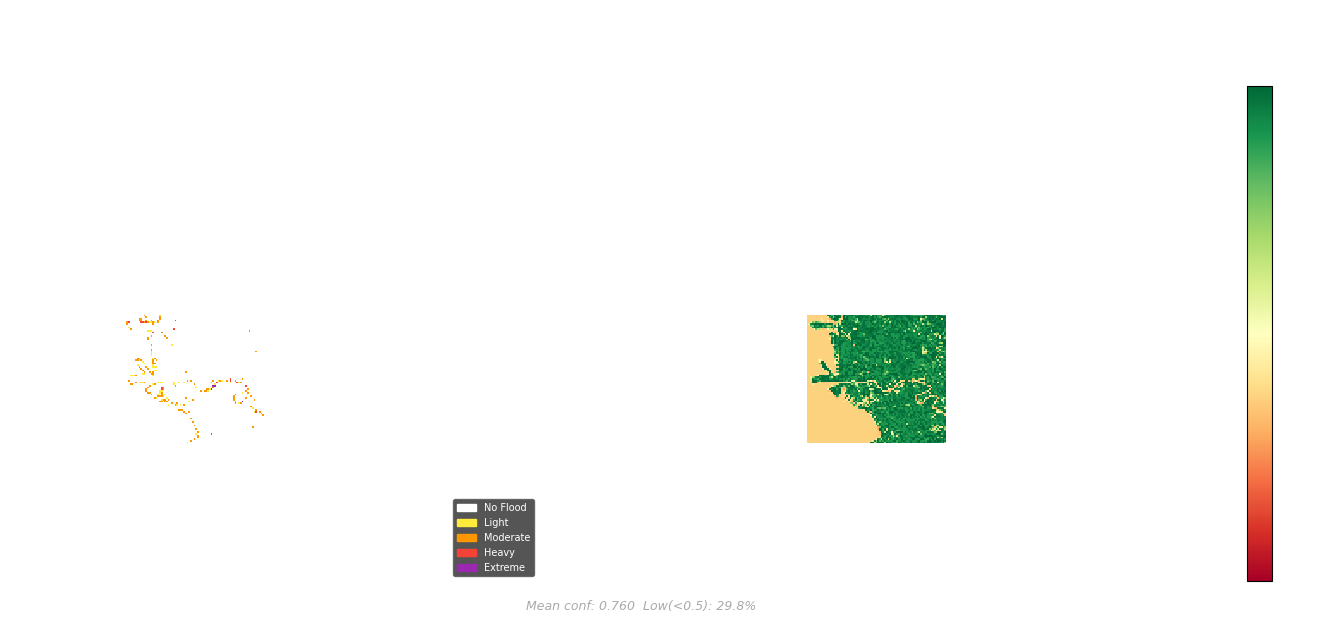

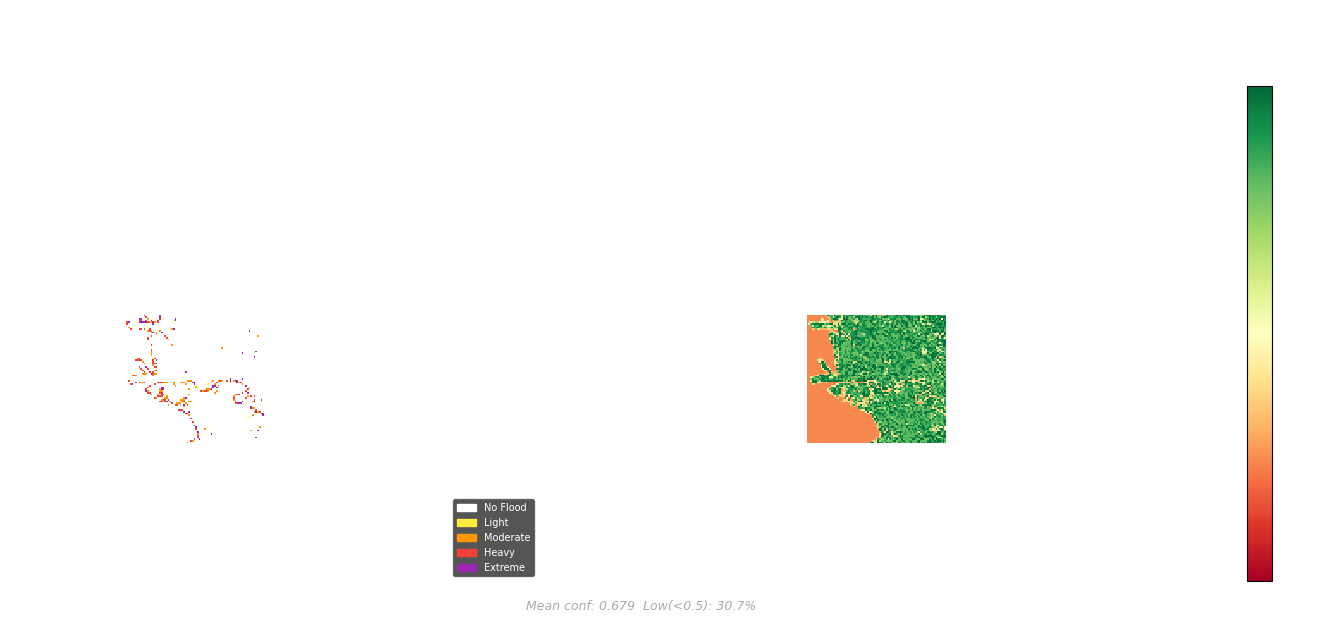

In [5]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

def visualize_prediction_tiff(tiff_path: str, title: str = None, figsize=(14, 6)):
    with rasterio.open(tiff_path) as src:
        flood_map = src.read(1)
        conf_map  = src.read(2)
        bounds    = src.bounds

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor('#FFFFFF')
    for ax in axes:
        ax.set_facecolor('#FFFFFF')

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]  

    # ── Band 1: Flood class map ───────────────────────────────────────────────
    nodata_mask  = flood_map < 0
    flood_masked = np.ma.masked_where(nodata_mask, flood_map)

    cmap = ListedColormap(['#FFFFFF', '#FFEB3B', '#FF9800', '#F44336', '#9C27B0'])
    cmap.set_bad(alpha=0)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

    axes[0].imshow(flood_masked, cmap=cmap, norm=norm,
                   extent=extent, interpolation='nearest', aspect='equal')
    axes[0].set_title('Predicted Flood Class', fontsize=12,    # ← was missing
                      fontweight='bold', color='white')
    axes[0].tick_params(colors='white', labelsize=7)
    for sp in axes[0].spines.values():
        sp.set_edgecolor('white')

    patches = [mpatches.Patch(color=c, label=l)
               for c, l in zip(
                   ['#FFFFFF', '#FFEB3B', '#FF9800', '#F44336', '#9C27B0'],
                   ['No Flood', 'Light', 'Moderate', 'Heavy', 'Extreme']
               )]
    axes[0].legend(handles=patches, loc='lower right', fontsize=7,
                   facecolor='#2a2a2a', labelcolor='white', edgecolor='#555555')

    # ── Band 2: Confidence map ────────────────────────────────────────────────
    valid_mask  = ~nodata_mask
    conf_masked = np.ma.masked_where(nodata_mask, conf_map)
    cmap_conf   = plt.cm.RdYlGn.copy()
    cmap_conf.set_bad(alpha=0)  # transparent here too for consistency

    im2 = axes[1].imshow(conf_masked, cmap=cmap_conf, vmin=0, vmax=1,
                         extent=extent, interpolation='nearest', aspect='equal')
    axes[1].set_title('Prediction Confidence', fontsize=12,
                      fontweight='bold', color='white')
    axes[1].tick_params(colors='white', labelsize=7)
    for sp in axes[1].spines.values():
        sp.set_edgecolor('white')

    cbar = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Confidence', fontsize=9, color='white')
    cbar.ax.tick_params(colors='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    # ── Stats annotation ──────────────────────────────────────────────────────
    valid_conf = conf_map[valid_mask]
    stats_text = (f"Mean conf: {valid_conf.mean():.3f}  "
                  f"Low(<0.5): {(valid_conf < 0.5).mean()*100:.1f}%")
    fig.text(0.5, 0.01, stats_text, ha='center', fontsize=9,
             color='#aaaaaa', style='italic')

    suptitle = title or tiff_path
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', color='white', y=1.01)
    plt.tight_layout()
    return fig

fig1 = visualize_prediction_tiff(
    'outputs/predictions/triangular_9mm_tpeak05.tif',
    title='Triangular Storm — 9mm, tpeak=0.5',
)
plt.show()

fig2 = visualize_prediction_tiff(
    'outputs/predictions/balanced_19mm.tif',
    title='Balanced Storm — 19mm',
)
plt.show()

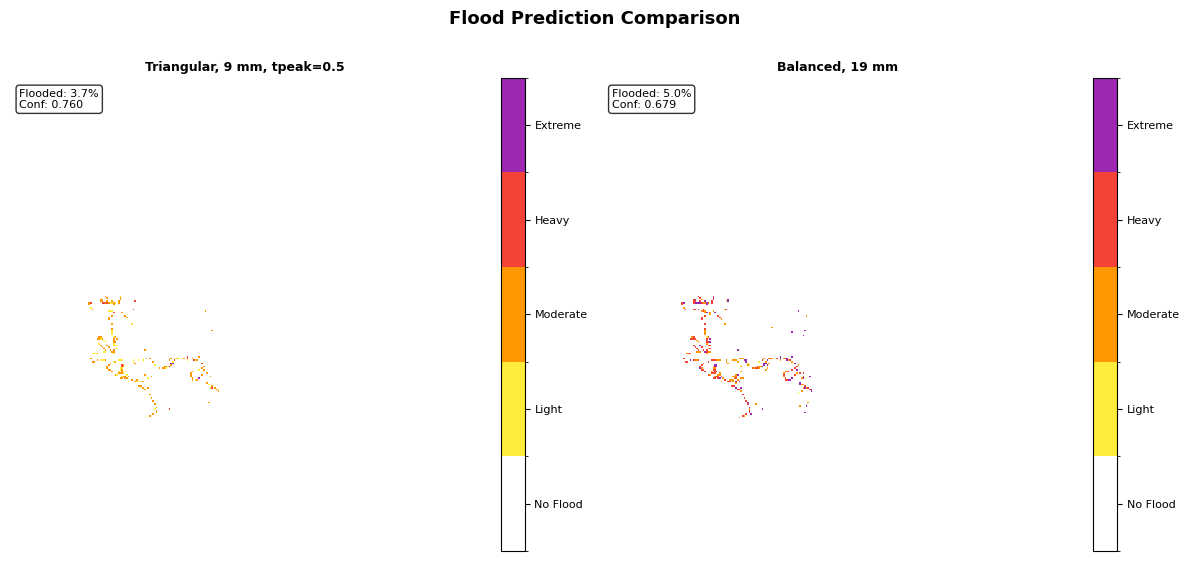

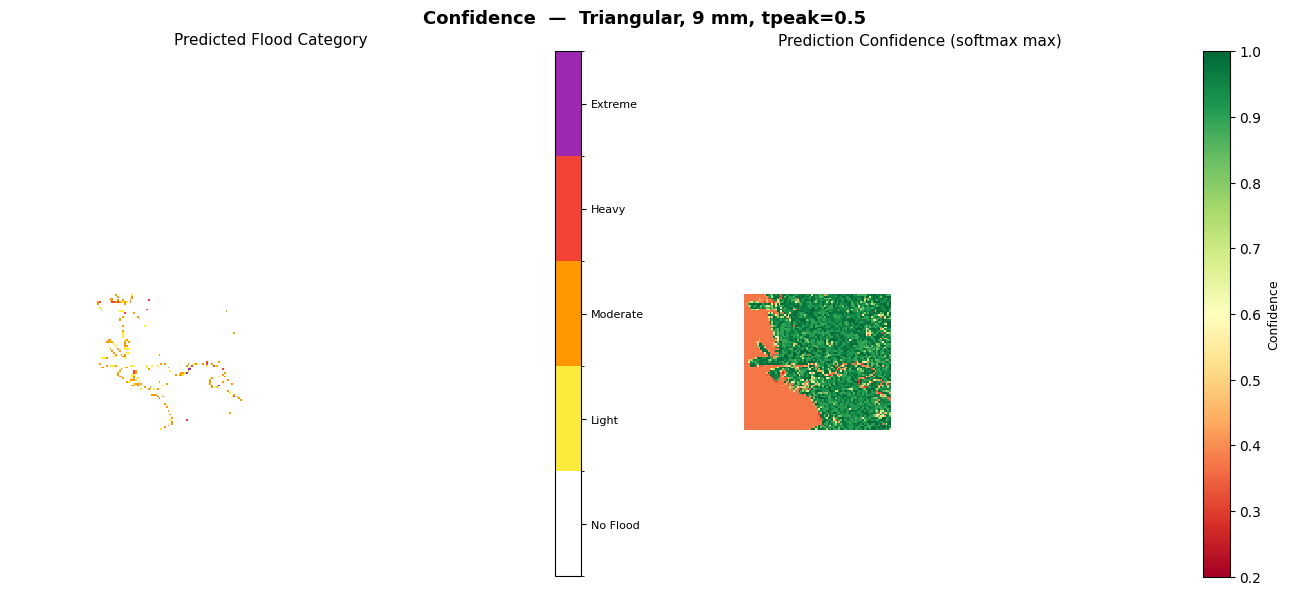

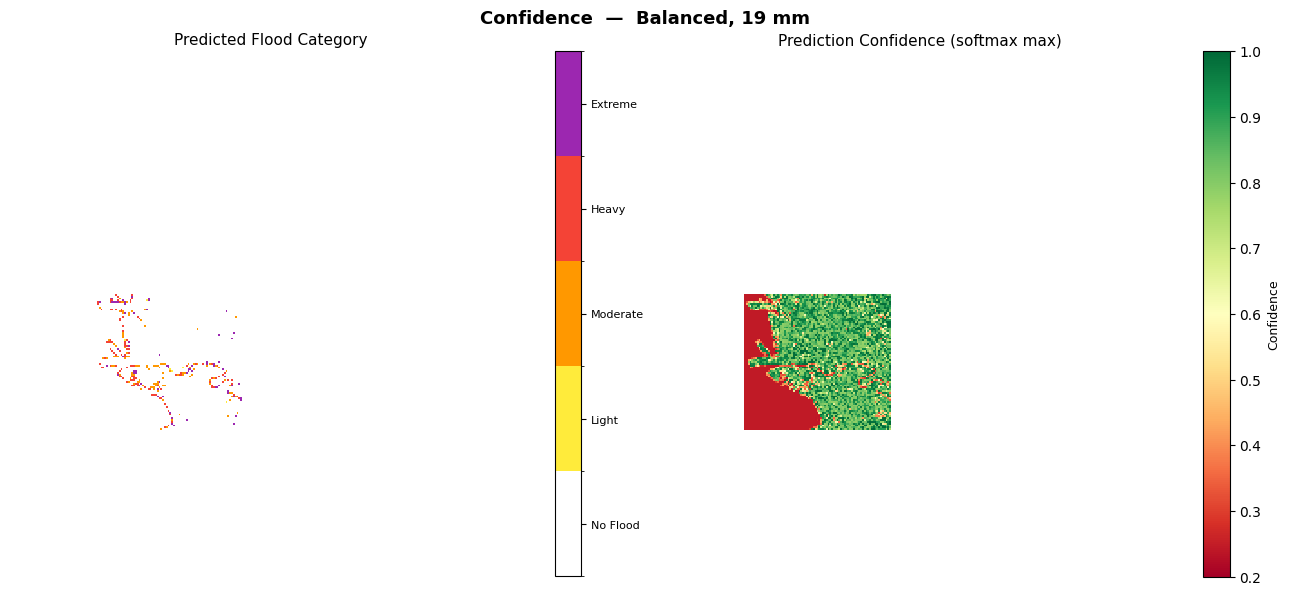

In [6]:
from visualize_inference import (plot_confidence, plot_comparison, plot_class_distribution, plot_hyetograph)
# Compare both storms on same scale
plot_comparison([result1, result2], engine)
# Where the model is uncertain
plot_confidence(result1, engine)
plot_confidence(result2, engine)